# Gaussian CDF OFF cell model with linear+exp recovery

In [33]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
from neo.io import NixIO
from quantities import s
from rvm_analysis.Spike2Tools import Spike2DataManager
from pathlib import Path
from rvm_analysis.trial_analysis_functions import create_trial_df
from pymc import model_to_graphviz
#! Force the backend back to matplotlib inline (after importing viziphant).
from rvm_analysis.bayesian_cell_models import plot_prior_predictive_checks


%matplotlib inline
from rvm_analysis.plotting import BrokenAxes
import json
print(plt.get_backend())
import os

module://matplotlib_inline.backend_inline


## Import trial data

In [34]:
from rvm_analysis.data_loaders import read_dataset_by_protocol


dm = read_dataset_by_protocol(['evoked','ongoing','evoked/ongoing'],base_data_path = Path("../../data/fm456/fm456/dandiset"))

ongoing ../../data/fm456/fm456/dandiset/sub-rat-68/sub-rat-68_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-68/sub-rat-68_ses-2.nwb
True
evoked ../../data/fm456/fm456/dandiset/sub-rat-15/sub-rat-15_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-78/sub-rat-78_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-56/sub-rat-56_ses-1.nwb
True
evoked/ongoing ../../data/fm456/fm456/dandiset/sub-rat-38/sub-rat-38_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-64/sub-rat-64_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-64/sub-rat-64_ses-2.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-59/sub-rat-59_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-72/sub-rat-72_ses-1.nwb
True
ongoing ../../data/fm456/fm456/dandiset/sub-rat-76/sub-rat-76_ses-1.nwb
True
evoked/ongoing ../../data/fm456/fm456/dandiset/sub-rat-47/sub-rat-47_ses-1.nwb
True
evoked/ongoing ../../data/fm456/fm456/dandiset/sub-rat-51/sub-r

In [35]:
base_path: Path = Path("./models/off_models/29_OFF_cells_linear_erf")
model_name ="off_trial_model.nc"
full_path = base_path / model_name
parameter_dictionary = base_path / "param_dict.json"

with open(parameter_dictionary,"r") as f:
    p: dict = json.load(f)

p

{'POST_EVENT_PERIOD': 100,
 'PRE_EVENT_PERIOD': -10,
 'SKIP': 1,
 'DRAWS': 1000,
 'TUNE': 1000,
 'BIN_SIZE': 0.05,
 'PRIORS': {'SIGMA_B': 4,
  'SIGMA_A': 5,
  'T_LOWER': -4,
  'T_UPPER': 4,
  'K': {'MU': 2, 'SIGMA': 2},
  'K2': {'MU': 2, 'SIGMA': 2},
  'K3': 2}}

In [36]:
import neo
def set_file_origins_for_blocks(blocks: list[neo.Block]):
    for block in blocks:
        block: neo.Block = block
        for child in block.children_recur:
            child.file_origin = block.file_origin

set_file_origins_for_blocks(dm.blocks)

off_flick_list, off_flick_list_by_cell = dm.plot_spikes_around_event("flick",p["PRE_EVENT_PERIOD"] * s,p["POST_EVENT_PERIOD"] * s,
                                                                             cell_type='OFF',sorted_by=None,color_by_file=False,
                                                                             save=None,plot=False)

[(array(90.3835894) * s, 'heat'), (array(101.0079252) * s, 'flick'), (array(1900.8621814) * s, 'heat'), (array(1911.3807232) * s, 'flick'), (array(1970.1713642) * s, 'heat'), (array(1978.71934) * s, 'flick')]
Next event [heat,1970.1713641999997 s] cuts off window
Next event [end,2052.0 s] cuts off window
1
[(array(23.6844946) * s, 'heat'), (array(31.8904456) * s, 'flick'), (array(1999.0749766) * s, 'heat'), (array(2006.3461626) * s, 'flick'), (array(2032.5114212) * s, 'heat'), (array(2043.4167832) * s, 'flick'), (array(2222.189892) * s, 'heat'), (array(2229.4174058) * s, 'flick')]
Next event [heat,2032.5114211999996 s] cuts off window
Next event [end,2259.0 s] cuts off window
2
[(array(23.6844946) * s, 'heat'), (array(31.8904456) * s, 'flick'), (array(1999.0749766) * s, 'heat'), (array(2006.3461626) * s, 'flick'), (array(2032.5114212) * s, 'heat'), (array(2043.4167832) * s, 'flick'), (array(2222.189892) * s, 'heat'), (array(2229.4174058) * s, 'flick')]
Next event [heat,2032.51142119999

,index,animal,cell,trial,time,count
0,0,CA_ongoing04a_cut_pared.smrx,0,0,-10.00,0
1,1,CA_ongoing04a_cut_pared.smrx,0,0,-9.95,0
2,2,CA_ongoing04a_cut_pared.smrx,0,0,-9.90,1
3,3,CA_ongoing04a_cut_pared.smrx,0,0,-9.85,0
4,4,CA_ongoing04a_cut_pared.smrx,0,0,-9.80,0
...,...,...,...,...,...,...
373995,373995,LHb_Mus25_CA2.smrx,59,2,99.75,0
373996,373996,LHb_Mus25_CA2.smrx,59,2,99.80,0
373997,373997,LHb_Mus25_CA2.smrx,59,2,99.85,0
373998,373998,LHb_Mus25_CA2.smrx,59,2,99.90,0


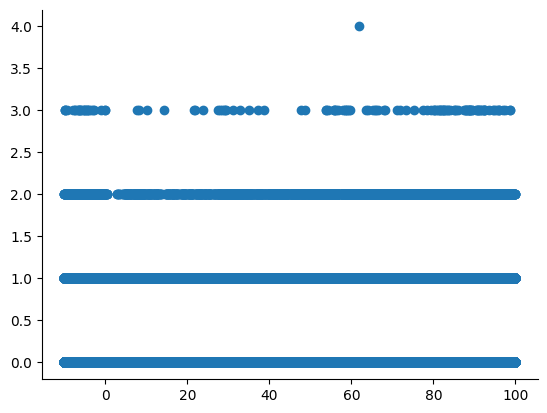

       time  count
0    -10.00     45
1     -9.95     57
2     -9.90     38
3     -9.85     50
4     -9.80     43
...     ...    ...
2195  99.75     35
2196  99.80     34
2197  99.85     28
2198  99.90     38
2199  99.95     34

[2200 rows x 2 columns]


In [37]:


df = create_trial_df(p["BIN_SIZE"] * s,off_flick_list_by_cell)
display(df)

# Plot the raw count data
plt.scatter(df['time'],df['count'])
plt.show()

counts = df.groupby('time',as_index=False)['count'].sum()
print(counts)
plt.show()

## Define Our Model

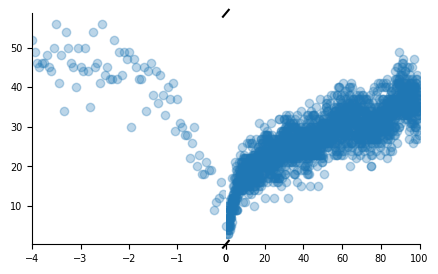

In [38]:
from rvm_analysis.bayesian_cell_models import create_X_and_Y_training_data


X_data,Y_data = create_X_and_Y_training_data(counts,skip=1,plot=True)

In [39]:
from rvm_analysis.bayesian_cell_models import build_erf_off_model,build_linear_erf_off_model


off_model = build_linear_erf_off_model(X_data,Y_data,p)

In [40]:
# model_to_graphviz(off_model,save=os.path.join(base_path,"graph.png")) # .render('model')

Sampling: [c_bar, erfoffset, erfscale, erfslope, k3, log_k2, t_switch, u0]
[distfit] >INFO> Sampling: [c_bar, erfoffset, erfscale, erfslope, k3, log_k2, t_switch, u0]


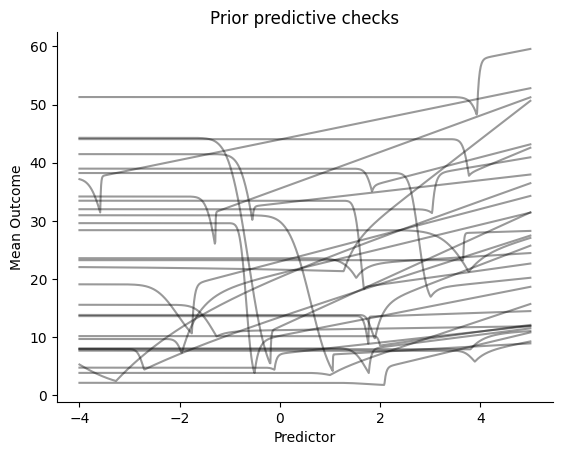

In [41]:
X_test = np.linspace(-4,5,1000)
plot_prior_predictive_checks(off_model,X_test,n_sample_paths=30)


## Sample from the model

In [42]:
from rvm_analysis.bayesian_cell_models import sample_model


SAMPLE = True
idata = sample_model(off_model,X_data,full_path,p,sample=SAMPLE,chains=4)



Auto-assigning NUTS sampler...
[distfit] >INFO> Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
[distfit] >INFO> Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
[distfit] >INFO> Multiprocess sampling (4 chains in 4 jobs)
NUTS: [erfoffset, erfscale, erfslope, log_k2, k3, t_switch, u0, c_bar]
[distfit] >INFO> NUTS: [erfoffset, erfscale, erfslope, log_k2, k3, t_switch, u0, c_bar]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
[distfit] >INFO> Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
There were 85 divergences after tuning. Increase `target_accept` or reparameterize.
[distfit] >ERROR> There were 85 divergences after tuning. Increase `target_accept` or reparameterize.


In [43]:

# # Calculate tau values and exponentiated HDIs
posterior = idata.posterior
derived_params = {
"k2": np.exp(posterior['log_k2']),
"k3": posterior['k3'],
"tau_post_fast": 1/np.exp(posterior['log_k2']),
# "tau_post_slow": 1/np.exp(posterior['log_k3']),
# "posterior_rate_diff": posterior['a'] - (posterior['c'] + posterior['d'] - posterior['u0'])
}

idata.posterior = idata.posterior.assign(**derived_params)

## Compute the model log likelihood and save

In [44]:
from rvm_analysis.bayesian_cell_models import compute_and_save_log_likelihood


COMPUTE_LL = True
loglik_save_path = base_path / "idata_with_log_liks.nc"

compute_and_save_log_likelihood(off_model,idata,save_path=loglik_save_path,recompute=COMPUTE_LL)

Computed from 4000 posterior samples and 2200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -6263.78    20.66
p_loo        4.77        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     2200  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [45]:
var_names=['erfscale','erfoffset','erfslope','c','k2',"k3","tau_post_fast","t_switch","u0"]

## Summarize the model

In [46]:
# Print a summary of the model parameters
summary = az.summary(idata,var_names=var_names)

display(summary)

summary.to_latex(os.path.join(base_path,"posterior_table_OFF_flick_linear_erf.tex"),index=True, escape=True,
                 float_format="%.3f")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
erfscale,21.283,0.462,20.390,22.115,0.021,0.015,501.0,489.0,1.00
erfoffset,4.664,0.693,3.281,5.798,0.033,0.024,447.0,265.0,1.01
erfslope,1.075,0.105,0.896,1.279,0.003,0.002,1122.0,1378.0,1.00
c,18.825,0.353,18.146,19.463,0.009,0.007,1420.0,2101.0,1.00
k2,0.204,0.023,0.163,0.246,0.001,0.000,1289.0,1004.0,1.00
k3,0.184,0.006,0.172,0.194,0.000,0.000,1465.0,1884.0,1.00
tau_post_fast,4.957,0.546,4.027,6.099,0.016,0.011,1289.0,1004.0,1.00
t_switch,0.978,0.206,0.591,1.350,0.008,0.006,676.0,458.0,1.00
u0,4.980,0.494,4.036,5.860,0.017,0.012,800.0,1136.0,1.01


array([[<Axes: title={'center': 'erfscale'}>,
        <Axes: title={'center': 'erfscale'}>],
       [<Axes: title={'center': 'erfoffset'}>,
        <Axes: title={'center': 'erfoffset'}>],
       [<Axes: title={'center': 'erfslope'}>,
        <Axes: title={'center': 'erfslope'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'k2'}>, <Axes: title={'center': 'k2'}>],
       [<Axes: title={'center': 'k3'}>, <Axes: title={'center': 'k3'}>],
       [<Axes: title={'center': 'tau_post_fast'}>,
        <Axes: title={'center': 'tau_post_fast'}>],
       [<Axes: title={'center': 't_switch'}>,
        <Axes: title={'center': 't_switch'}>],
       [<Axes: title={'center': 'u0'}>, <Axes: title={'center': 'u0'}>]],
      dtype=object)

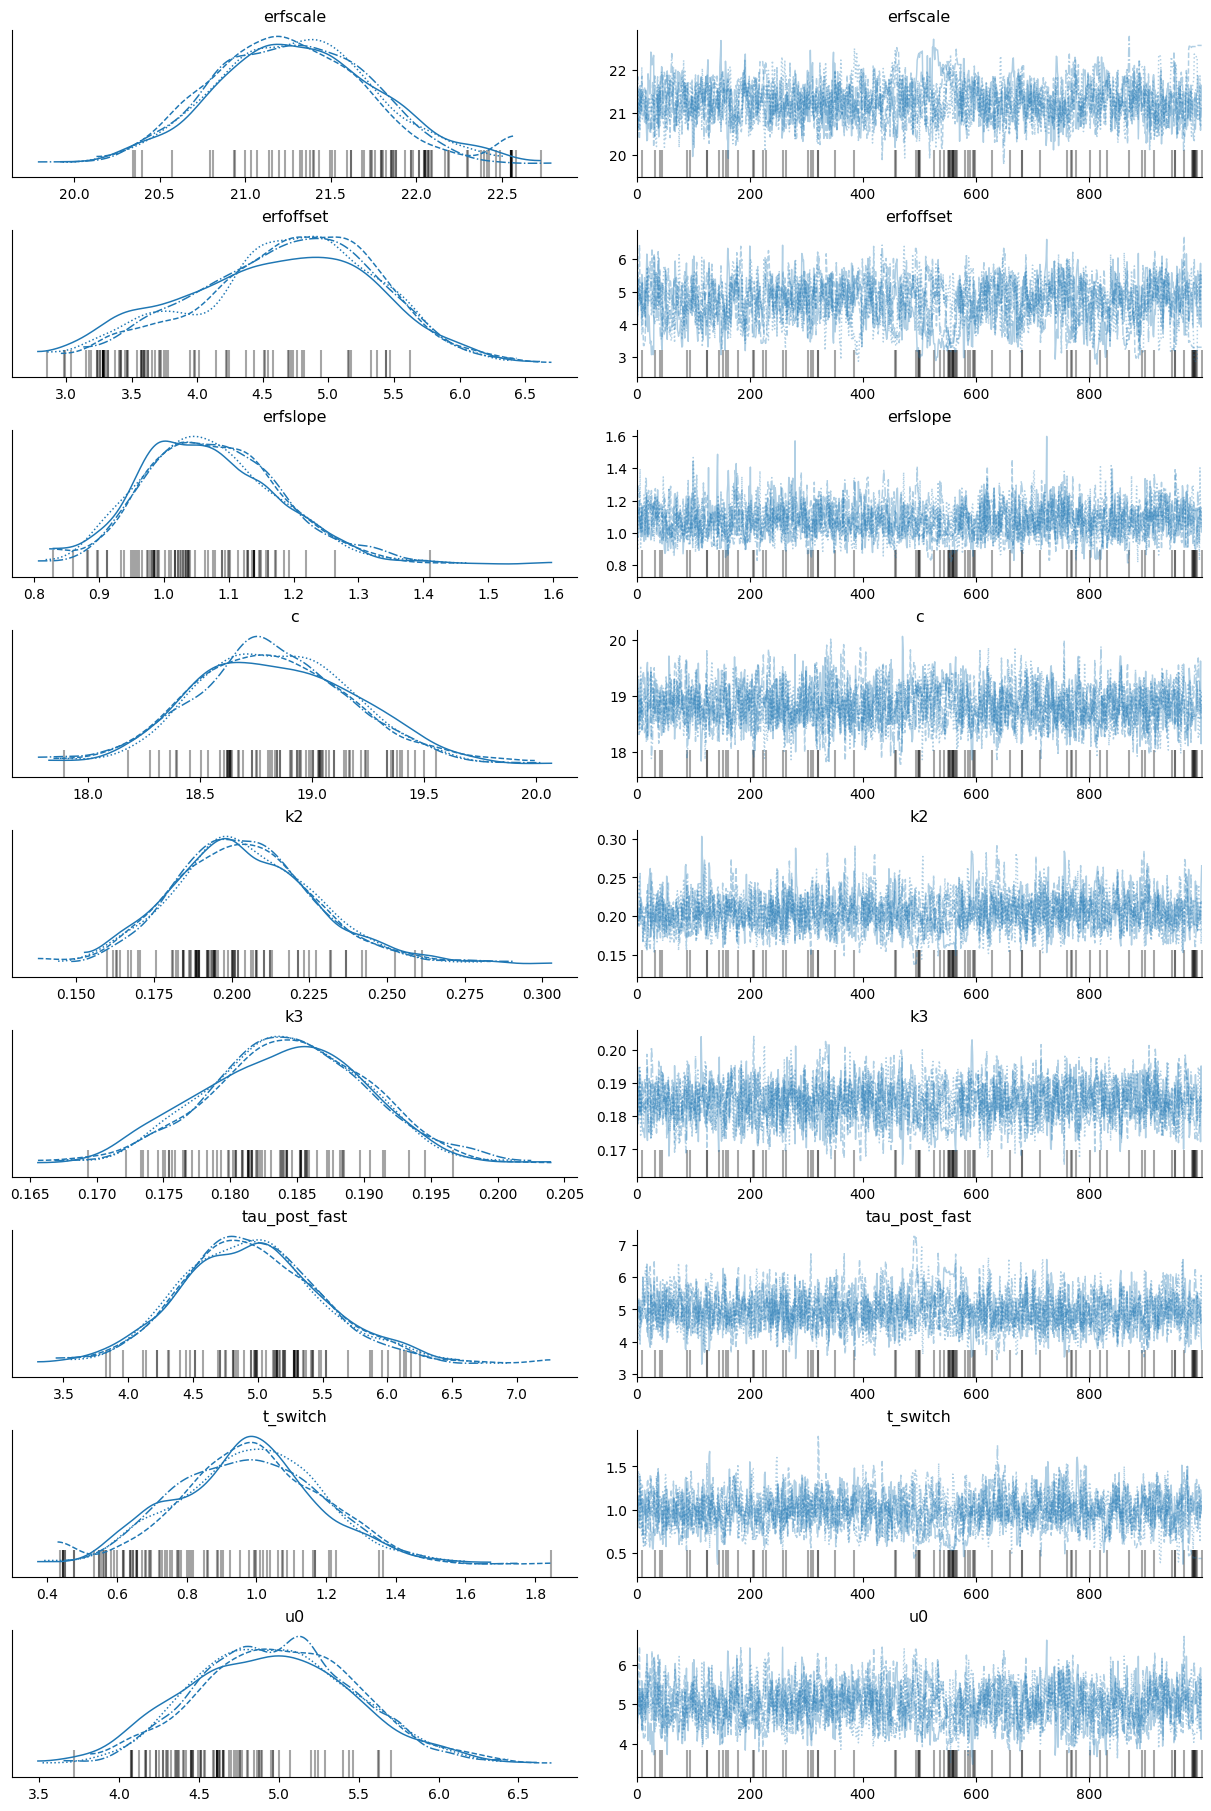

In [47]:
# plot the traces of the model
az.plot_trace(idata,backend_kwargs={'layout': 'constrained'},
              var_names=var_names
              )

## Compute predictions over a set of new input points

In [48]:
from rvm_analysis.bayesian_cell_models import compute_predictions_over_new_data


X_test = np.linspace(-10,100,2000)
idata_predictions = compute_predictions_over_new_data(off_model,idata,X_test)

Sampling: [count_pred_new]
[distfit] >INFO> Sampling: [count_pred_new]


In [49]:

# Extract posterior lambda and summarize
lambda_preds = idata_predictions.predictions['rate']
lambda_mean = lambda_preds.mean(("chain","draw"))
# lambda_mean

count_preds = idata_predictions.predictions['count_pred_new']
count_pred_mean = count_preds.mean(("chain","draw"))

In [50]:
preds_numpy = count_preds.to_numpy()
print(preds_numpy.shape)
preds_numpy = preds_numpy.T.reshape((2000,-1))
preds_numpy.shape

(4, 1000, 2000)


(2000, 4000)

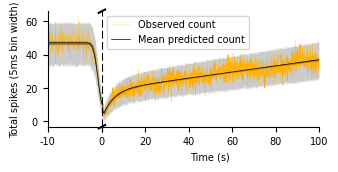

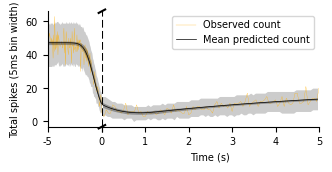

In [51]:
from rvm_analysis.plotting import plot_predictions_paper


plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy,x_bounds=(-10,100),figsize=(3.5,1.5),
                       filename="29_switching_model_OFF_cells_linear_erf_aggregated",
                   basePath="./models/off_models/29_OFF_cells_linear_erf",save=True)

plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy,x_bounds=(-5,5),figsize=(3.5,1.5),
                       filename="29_switching_model_OFF_cells_linear_erf_aggregated_zoom_in",
                   basePath="./models/off_models/29_OFF_cells_linear_erf",save=True)